# TS0: Primeros pasos en la simulación
### Nicolás Bravo Behnke
## En este trabajo se utilizará codigo del leguaje python para generar señales senoidales de distintas frecuencias y graficarlas.
## A su vez se va a analizar que ocurre con la señal cuando la frecuencia de trabajo se acerca a la frecuencia de Nyquist-Shannon y que ocurre cuando la frecunecia de trabajo supera la frecuencia de muestreo.

### Codigo a utilizar:

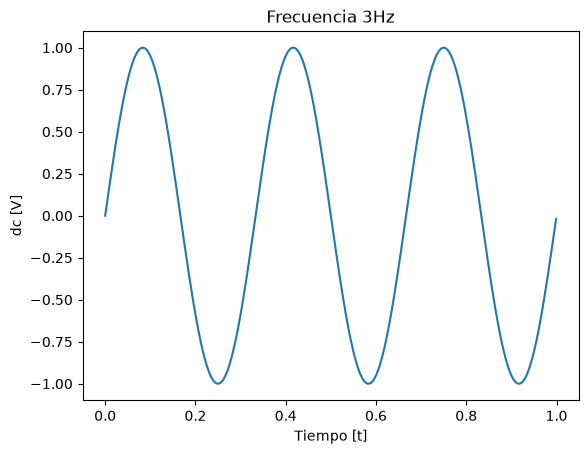

In [1]:
import numpy as np
import matplotlib.pyplot as plt


#%% Definiciones

N = 1000 #[muestras]  Cant de muestras
fs = 1000 #[Hz]       Frecuencia de muestras


#%%  Funciones
def mi_funcion_sen( vmax = 1, dc = 0, ff = 1, ph=0, nn = N, fs = fs):
    
    tt = np.arange(start=0, stop=nn/fs, step=1/fs)
    xx = vmax*np.sin(2*np.pi * ff * tt + ph) + dc
    
    return (tt, xx)
#%% Uso de funciones

vmax = 1        #[volts]
dc = 0      #[volts]
ff = 3        #[Hz] "ciclos que entran en la muestra
ph = 0      #[rad]
nn = N      #[muestras]
fs = fs         #[Hz]

tt, xx = mi_funcion_sen(vmax, dc, ff, ph, nn, fs)
plt.title(f"Frecuencia {ff}Hz")
plt.xlabel("Tiempo [t]")
plt.ylabel("dc [V]")
plt.plot(tt, xx)

### Primero graficamos una onda de frecuencia 500Hz, esta es la frecuencia de Nyquist-Shannon para este caso, ya que esta es la mitad de la frecuencia de muestreo (fs).

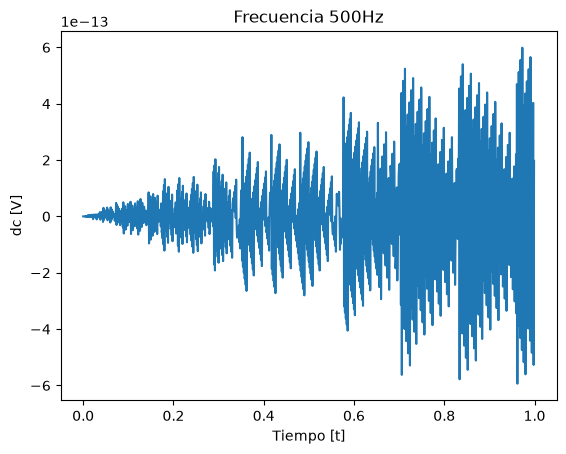

In [2]:
ff = 500
tt, xx = mi_funcion_sen(vmax, dc, ff, ph, nn, fs)
plt.title(f"Frecuencia {ff}Hz")
plt.xlabel("Tiempo [t]")
plt.ylabel("dc [V]")
plt.plot(tt, xx)

### Como se puede apreciar, al poner la frecuencia de trabajo en la frecuencia de Nyquist-Shannon, los puntos del muestreo estan muy separados entre si haciendo imposible una reconstruccion precisa de la señal.

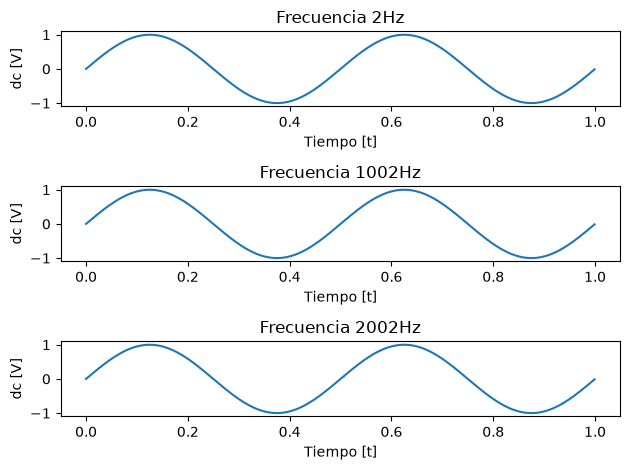

In [3]:
ff = 2
ff2 = 1002
ff3 = 2002
tt, xx = mi_funcion_sen(vmax, dc, ff, ph, nn, fs)
plt.subplot(311)
plt.title(f"Frecuencia {ff}Hz")
plt.xlabel("Tiempo [t]")
plt.ylabel("dc [V]")
plt.plot(tt, xx)

tt2, xx2 = mi_funcion_sen(vmax, dc, ff2, ph, nn, fs)
plt.subplot(312)
plt.title(f"Frecuencia {ff2}Hz")
plt.xlabel("Tiempo [t]")
plt.ylabel("dc [V]")
plt.plot(tt2, xx2)


tt3, xx3 = mi_funcion_sen(vmax, dc, ff3, ph, nn, fs)
plt.subplot(313)
plt.title(f"Frecuencia {ff3}Hz")
plt.xlabel("Tiempo [t]")
plt.ylabel("dc [V]")
plt.plot(tt3, xx3)
plt.tight_layout()

### Se puede ver que al usar una frecuencia $ff = fs*n + f_{0} $, las señales son iguales. Esto se debe a que al muestrear una señal el espectro tiene replicas separadas cada fs, dando asi las señales iguales a la original. Aunque las señales continuas no sean iguales, al muestrearlas pueden producir la misma señal. Este efecto se llama aliasing.

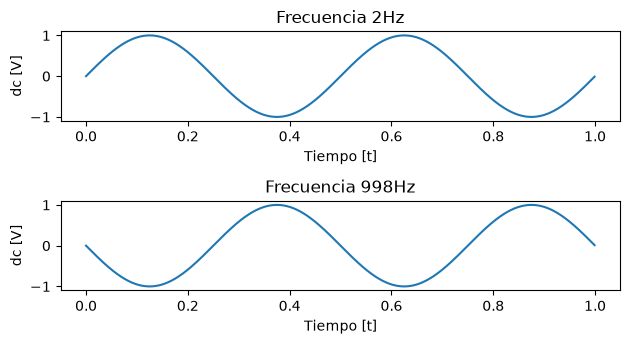

In [4]:
ff = 2
ff2 = 998
tt, xx = mi_funcion_sen(vmax, dc, ff, ph, nn, fs)
plt.subplot(311)
plt.title(f"Frecuencia {ff}Hz")
plt.xlabel("Tiempo [t]")
plt.ylabel("dc [V]")
plt.plot(tt, xx)

tt2, xx2 = mi_funcion_sen(vmax, dc, ff2, ph, nn, fs)
plt.subplot(312)
plt.title(f"Frecuencia {ff2}Hz")
plt.xlabel("Tiempo [t]")
plt.ylabel("dc [V]")
plt.plot(tt2, xx2)
plt.tight_layout()

### En este caso, las señales se encuentran espejadas debido a que al usar una frecuencia $ff= fs*n - f_{0}$, la frecuencia se encuentra del lado opuesto del espectro de la señal.